# 🌌 Predicting Stellar Class | Multi-Model Ensemble
**Competition:** Playground Series S6E6  
**Goal:** Classify celestial objects into **GALAXY**, **STAR**, or **QSO** (Quasar)

---

##  Problem Overview
We are given astronomical data from Sloan Digital Sky Survey (SDSS). Our task is to predict the class of stellar objects using features like magnitudes, redshift, spectral type, etc.

---

##  Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
import xgboost as xgb
import lightgbm as lgb

def print_header(title):
    print("\n" + "="*40)
    print(f" {title}")
    print("="*40)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Load Data

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
sample = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
train.head()

,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


#  Exploratory Data Analysis


In [3]:
print("Train Shape:", train.shape)
print("Test Shape:", test.shape)
print("\nColumns:", train.columns.tolist())

# describe
print_header("Describtion")
display(train.describe())

# info
print_header("Information")
print(train.info())

# Missing values
print_header("Missing Values:")
display(train.isnull().sum())

Train Shape: (577347, 12)
Test Shape: (247435, 11)

Columns: ['id', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift', 'spectral_type', 'galaxy_population', 'class']

 Describtion


,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780



 Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB
None

 Missing Values:


id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64

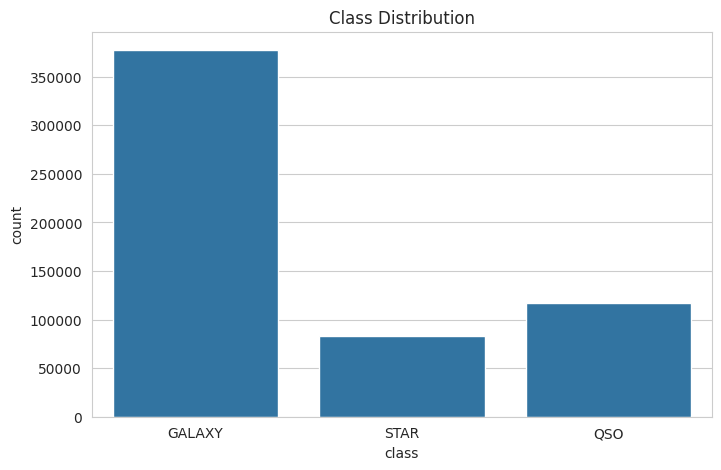

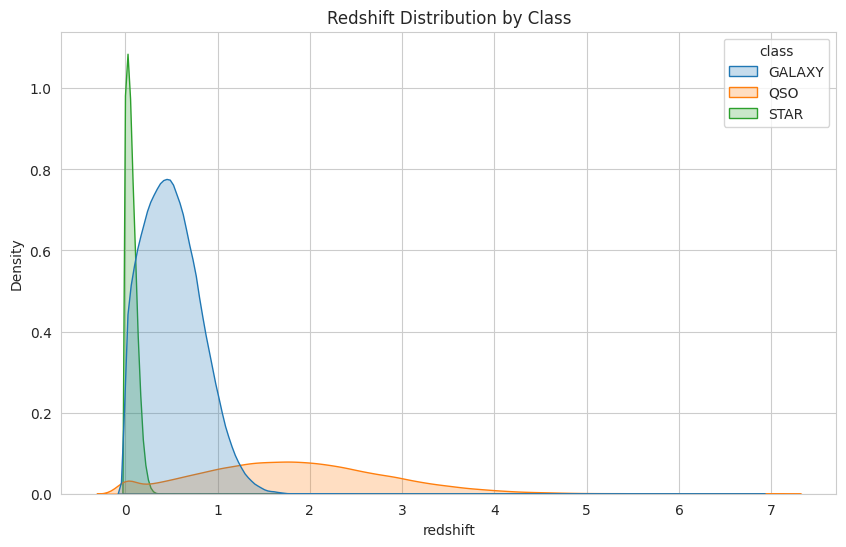

In [4]:
# Target Distribution
plt.figure(figsize=(8,5))
sns.countplot(data=train, x='class', order=['GALAXY', 'STAR', 'QSO'])
plt.title('Class Distribution')
plt.show()

# Redshift distribution by class
plt.figure(figsize=(10,6))
sns.kdeplot(data=train, x='redshift', hue='class', fill=True)
plt.title('Redshift Distribution by Class')
plt.show()



  
- `GALAXY` is the most common class.  
- `Redshift` is a very strong feature for distinguishing between classes (especially Quasars have higher redshift).

##  Feature Engineering

In [5]:
# Color Indices
for df in [train, test]:
    df['u_g'] = df['u'] - df['g']
    df['g_r'] = df['g'] - df['r']
    df['r_i'] = df['r'] - df['i']
    df['i_z'] = df['i'] - df['z']
    
    df['mean_mag'] = df[['u','g','r','i','z']].mean(axis=1)
    df['mag_range'] = df[['u','g','r','i','z']].max(axis=1) - df[['u','g','r','i','z']].min(axis=1)

# Encode Categorical Features
cat_cols = ['spectral_type', 'galaxy_population']
for col in cat_cols:
    le = LabelEncoder()
    train[col] = le.fit_transform(train[col])
    test[col] = le.transform(test[col])

# Encode Target
target_le = LabelEncoder()
train['class_encoded'] = target_le.fit_transform(train['class'])

feature_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift',
                'spectral_type', 'galaxy_population', 'u_g', 'g_r', 'r_i', 'i_z',
                'mean_mag', 'mag_range']

X = train[feature_cols]
y = train['class_encoded']
test_final = test[feature_cols]

print("Feature Engineering Completed!")

Feature Engineering Completed!


 
**Created color difference features (`u-g`, `g-r`, etc.) which are crucial in astrophysics for object classification. Also added mean magnitude and magnitude range.**

##  Data Preprocessing

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_final)

X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, 
                                                  test_size=0.2, 
                                                  random_state=42, 
                                                  stratify=y)

print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

Training samples: 461877
Validation samples: 115470



**Scaled all features** and split data while maintaining class balance using `stratify`.

# Model Training (Multi-Model)

In [7]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=200,     
        max_depth=10, 
        n_jobs=-1, 
        random_state=42
    ),
       "XGBoost": xgb.XGBClassifier(
        n_estimators=200,      
        learning_rate=0.1,
        max_depth=5,           
        random_state=42,
        tree_method='hist',   
        eval_metric='mlogloss'
    ), 
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200, 
        learning_rate=0.1,
        max_depth=5, 
        random_state=42,
        verbose=-1,
          force_col_wise=True)
}

results = {}

for name, model in models.items():
    print(f"Training {name} ")
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    acc = accuracy_score(y_val, pred)
    results[name] = acc
    print(f"{name:20} → Accuracy: {acc:.5f}\n")

Training Logistic Regression 
Logistic Regression  → Accuracy: 0.92717

Training Random Forest 
Random Forest        → Accuracy: 0.95174

Training XGBoost 
XGBoost              → Accuracy: 0.96359

Training LightGBM 
LightGBM             → Accuracy: 0.96523



Trained 4 different models. **XGBoost(0.96359)** and **LightGBM(0.96523)** usually perform best on tabular astronomical data.

# Ensemble Model ( Classifier)

In [8]:
voting = VotingClassifier(
    estimators=[
        ('rf', models['Random Forest']),
        ('xgb', models['XGBoost']),
        ('lgb', models['LightGBM'])
    ],
    voting='soft',
    weights=[2, 3, 3]
)

voting.fit(X_train, y_train)

voting_pred = voting.predict(X_val)

print("Classifier Accuracy:", accuracy_score(y_val, voting_pred))
print("\nClassification Report:\n")
print(classification_report(
    y_val,
    voting_pred,
    target_names=target_le.classes_
))

Classifier Accuracy: 0.9640079674374297

Classification Report:

              precision    recall  f1-score   support

      GALAXY       0.97      0.98      0.97     75496
         QSO       0.96      0.96      0.96     23429
        STAR       0.92      0.91      0.92     16545

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470



# Model Evaluation

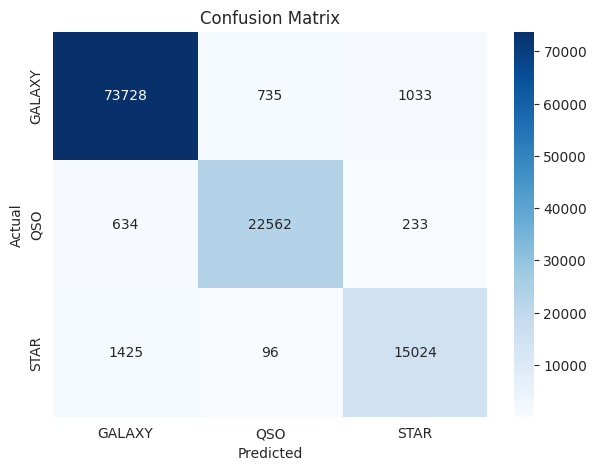

In [9]:
cm = confusion_matrix(y_val, voting_pred)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_le.classes_, 
            yticklabels=target_le.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Feature Importance

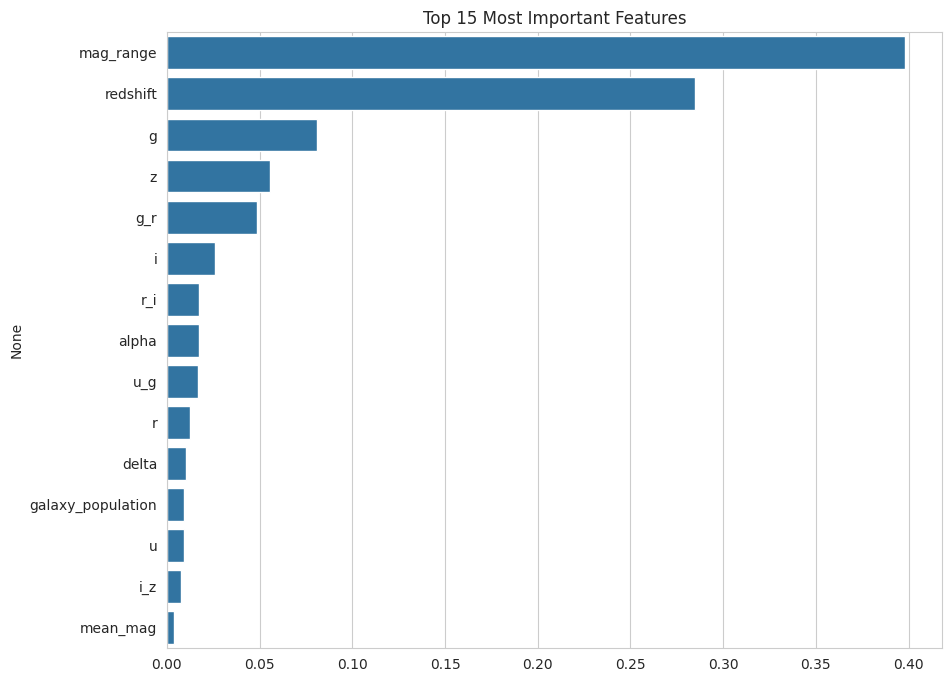

In [10]:
importances = models['XGBoost'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=feat_imp.values[:15], y=feat_imp.index[:15])
plt.title('Top 15 Most Important Features')
plt.show()

# Final Submission

In [11]:
final_pred = voting.predict(test_scaled)
final_labels = target_le.inverse_transform(final_pred)

submission = pd.DataFrame({
    'id': test['id'],
    'class': final_labels
})

submission.to_csv('submission.csv', index=False)
print("Submission file saved successfully!")


Submission file saved successfully!


#### What I Learned From This Competition

- **Redshift** is an incredibly powerful feature — it completely changed the game.
- Color indices like **u-g** and **g-r** work like magic for classifying stars, galaxies, and quasars.
- **XGBoost** + **LightGBM** together make the ultimate powerful combination on Kaggle🙃.
- Even a **random forest** sometimes wins hearts 😜.